<a href="https://colab.research.google.com/github/alejandrosantanabonilla/AI_tutorials/blob/main/UMAP_HDBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To make this work pedagogically, we need to show the students the raw geometry first, let HDBSCAN find the clusters, and *then* plot it again with the colors applied. This gives them a fantastic visual "Ah-ha!" moment where the gray blobs suddenly light up with meaning.

Here is the fully updated lesson plan, ready to be pasted directly into Google Colab.

---

### [Text Cell]

# Day 1 Capstone: From Discovery to Weak Supervision

Welcome to the final lab of Day 1!

So far, we have explored the geometry of data. We measured distances between customers, shrank high-dimensional space down to 2D using **UMAP**, and found dense neighborhoods using **HDBSCAN**.

**The Production Problem:**
UMAP and HDBSCAN are incredible for *discovering* patterns, but they are terrible for *real-time predictions*. If a new customer clicks on our website, we can't recalculate the UMAP manifold for our entire database just to figure out what segment they belong to—it takes too long!

**The Solution (Weak Supervision):**
We are going to use our slow, complex unsupervised models to generate labels for our data today. Tomorrow, we will use those labels to train a lightning-fast Random Forest that can instantly categorize new customers. This pipeline is called *Cluster-then-Predict* or *Weak Supervision*.

---

### [Code Cell]

In [1]:
# 1. ENVIRONMENT SETUP & DATA GENERATION
# Run this cell to install our advanced libraries and generate our workshop dataset.

!pip install -q hdbscan umap-learn

import pandas as pd
import numpy as np
import hdbscan
import umap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- Generating our Synthetic "KNIME Customer Churn" Dataset ---
np.random.seed(42)

# Profile A: "Happy Veterans" - High tenure, low support calls, moderate charges
profile_a = pd.DataFrame({
    'CustomerID': range(1, 901),
    'Tenure_Months': np.random.normal(55, 10, 900),
    'Monthly_Charges': np.random.normal(65, 15, 900),
    'Num_Support_Calls': np.random.poisson(1, 900),
    'Churn_Label': np.zeros(900) # 0 = Stayed
})

# Profile B: "Frustrated Newbies" - Low tenure, high support calls, high charges
profile_b = pd.DataFrame({
    'CustomerID': range(901, 1501),
    'Tenure_Months': np.random.normal(8, 4, 600),
    'Monthly_Charges': np.random.normal(105, 20, 600),
    'Num_Support_Calls': np.random.poisson(5, 600),
    'Churn_Label': np.ones(600) # 1 = Churned
})

df = pd.concat([profile_a, profile_b]).sample(frac=1, random_state=42).reset_index(drop=True)
df['Tenure_Months'] = df['Tenure_Months'].clip(lower=1).astype(int)
df['Monthly_Charges'] = df['Monthly_Charges'].clip(lower=15).round(2)

print("✅ Environment ready and dataset loaded!")

✅ Environment ready and dataset loaded!


---

### [Text Cell]

## Step 1: The Constructivist Rule (Hiding the Truth)

Because we are doing *unsupervised* learning today, we must mathematically blindfold our algorithms. If we let the models see the actual `Churn_Label`, it's cheating!

We also need to scale our features so that large numbers (like $150 monthly charges) don't dominate small numbers (like 2 support calls) purely because of their magnitude.

---

### [Code Cell]

In [2]:
# Drop arbitrary IDs and the target label
features = df.drop(columns=['CustomerID', 'Churn_Label'])

# Scale the geometry ($L_2$ norm stability)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print(f"Shape of our feature matrix: {scaled_features.shape}")

Shape of our feature matrix: (1500, 3)


---

### [Text Cell]

## Step 2: Shrinking the Space

We use UMAP to crush our multi-dimensional behavioral data down to 2 dimensions. This maintains the local topology (neighbors stay close to neighbors) while making it much easier for HDBSCAN to find dense pockets.

---

### [Code Cell]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


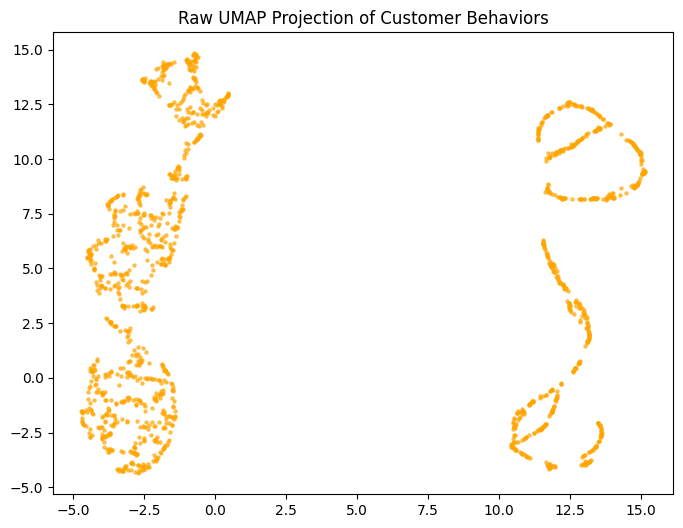

In [4]:
# Reduce dimensions
reducer = umap.UMAP(n_components=2, metric='euclidean', random_state=42)
umap_embeddings = reducer.fit_transform(scaled_features)

# Let's peek at the raw geometry we just created (without labels)
plt.figure(figsize=(8, 6))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], s=5, color='orange', alpha=0.6)
plt.title("Raw UMAP Projection of Customer Behaviors")
plt.show()

---

### [Text Cell]

## Step 3: Weak Supervision (Creating Pseudo-Labels)

Now we ask HDBSCAN to find the natural groupings in that 2D space. HDBSCAN looks for areas of high density separated by areas of low density. Once it assigns the labels, we will plot the exact same UMAP projection, but colored by the clusters!

---

### [Code Cell]

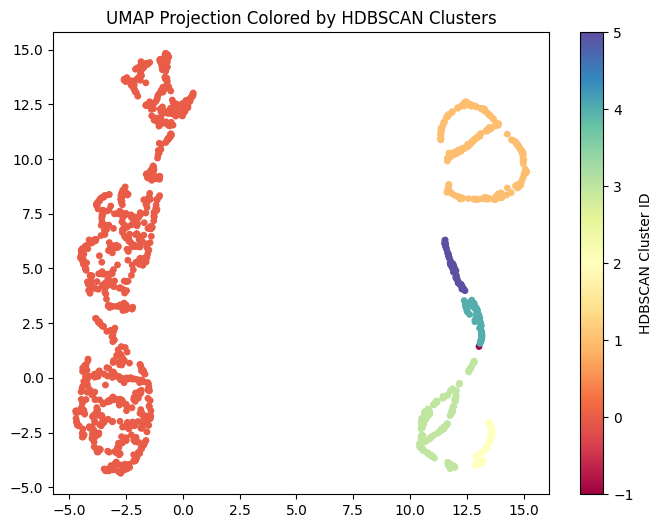


Cluster Counts:
Pseudo_Label
 0    900
 1    263
 3    162
 5     60
 4     59
 2     55
-1      1
Name: count, dtype: int64


In [5]:
# Find the clusters
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=10)
pseudo_labels = clusterer.fit_predict(umap_embeddings)

# Attach the new labels back to our original DataFrame
df['Pseudo_Label'] = pseudo_labels

# Plot the UMAP geometry again, this time colored by the HDBSCAN labels!
plt.figure(figsize=(8, 6))
scatter = plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=pseudo_labels, s=15, cmap='Spectral')
plt.colorbar(scatter, label='HDBSCAN Cluster ID')
plt.title("UMAP Projection Colored by HDBSCAN Clusters")
plt.show()

# Let's see how many customers were assigned to each cluster
print("\nCluster Counts:")
print(df['Pseudo_Label'].value_counts())

---

### [Text Cell]

> **Instructor Discussion Prompt:** Look at the output above. You have Cluster 0, Cluster 1... and a cluster labeled `-1` (usually dark purple/blue on the Spectral map). What do you think `-1` represents?

**The Answer:** HDBSCAN's superpower is its refusal to force ambiguous data into a cluster. The `-1` label represents **noise** or outliers. Because we are generating a training dataset for Day 2, we only want our supervised models to learn from highly confident, distinct patterns. We need to drop the noise.

---

### [Code Cell]

In [6]:
# Filter out the noise points
clean_df = df[df['Pseudo_Label'] != -1].copy()

print(f"Original dataset size: {len(df)} customers")
print(f"High-confidence size: {len(clean_df)} customers retained for Day 2")

Original dataset size: 1500 customers
High-confidence size: 1499 customers retained for Day 2


---

### [Text Cell]

## Step 4: The Sanity Check (Business Profiling)

Never trust an algorithm blindly. Do these mathematical clusters actually mean anything in the real world?

Let's group our raw data by our newly discovered `Pseudo_Label` and look at the average behaviors of each cluster.

---

### [Code Cell]

In [7]:
profiling_cols = ['Tenure_Months', 'Monthly_Charges', 'Num_Support_Calls']
segment_profiles = clean_df.groupby('Pseudo_Label')[profiling_cols].mean().round(2)

print("\n--- Cluster Profiles ---")
display(segment_profiles)


--- Cluster Profiles ---


,Tenure_Months,Monthly_Charges,Num_Support_Calls
Pseudo_Label,,,
0,54.66,66.16,0.96
1,7.76,101.85,3.13
2,7.47,112.11,6.00
3,7.62,102.08,7.17
4,7.93,117.76,5.00
5,6.98,91.73,5.00


---

### [Text Cell]

> **Instructor Discussion Prompt:** Look at the averages for Cluster 0 and Cluster 1. If you were the Marketing Director, what names would you give to these two distinct groups of people?

Notice what just happened: **The math discovered actual human behavioral profiles without ever being told what to look for.**

## Step 5: Export for Tomorrow

We have successfully manufactured our own target variable. We will save this clean dataset, and tomorrow morning, `Pseudo_Label` becomes the `y` target for our Decision Trees!

---

### [Code Cell]

In [8]:
# Save the clean dataset
clean_df.to_csv('day2_training_data.csv', index=False)
print("✅ Labels generated. Dataset saved. We are ready for Day 2!")

✅ Labels generated. Dataset saved. We are ready for Day 2!
